# 2.5D Attention U-Net++ — BraTS 2020

**입력**: `(B, 20, 192, 192)` — adjacent 5 slices × 4 modality  
**아키텍처**: U-Net++ + SE Block (channel attention) + Attention Gate (spatial)  
**출력**: `(B, 3, 192, 192)` — WT / TC / ET (deep supervision 포함)

---

### 설계 결정 근거

| 항목 | 결정 | 이유 |
|------|------|------|
| 입력 채널 | 20 (5 slices × 4 modality) | ±2 slice 문맥으로 slice 간 연속성 반영 |
| Attention | SE Block + Attention Gate | 채널 중요도 + 공간적 skip 필터링 |
| Skip 연결 | Nested dense (U-Net++) | 세밀한 경계 복원 |
| Deep supervision | 4개 head 평균 | 기울기 소실 방지, ET 성능 향상 |
| 전처리 저장 | float16 compressed npz (환자별) | 디스크 ~13GB, 로딩 속도 우수 |
| 경계 처리 | edge-replicate padding | 첫/마지막 slice에서 out-of-bounds 방지 |

### ⚠️ 주요 위험 요소 및 대응

| 위험 | 원인 | 대응 |
|------|------|------|
| 메모리 증가 | 20채널 입력 (2D 대비 5×) | 배치 크기 8로 축소, AMP 사용 |
| GroupNorm 채널 수 | 32의 배수만 가능 | features=[32,64,128,256,512] 고정 |
| 경계 slice 정보 누락 | z=0,1,D-2,D-1에서 인접 slice 없음 | np.clip으로 edge replication |
| 전처리 RAM 사용 | 환자 데이터 전체 캐시 | 캐시 크기 제한 (CACHE_SIZE 설정) |
| Deep supervision 불균형 | 초기에 얕은 head가 지배 | weight decay: 1.0→0.5→0.25→0.125 |

In [13]:
import subprocess, sys
for pkg in ['nibabel', 'monai', 'scikit-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✓ 설치 완료')

You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.


✓ 설치 완료


You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.


In [14]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import nibabel as nib
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('✓ Device: mps (Metal GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ Device: cuda ({torch.cuda.get_device_name()})')
else:
    DEVICE = torch.device('cpu')
    print('Device: cpu (느림 — GPU 권장)')

print(f'PyTorch: {torch.__version__}')

✓ Device: mps (Metal GPU)
PyTorch: 2.8.0


In [15]:
# ── 경로 설정 ──────────────────────────────────────────────────
candidates = [
    Path.home() / 'Desktop' / 'brats_work' / 'brats20-dataset-training-validation',
    Path.home() / 'Downloads'  / 'brats20-dataset-training-validation',
    Path.cwd() / 'brats20-dataset-training-validation',
    Path('/kaggle/input/brats20-dataset-training-validation'),
]
DATA_ROOT = next((p for p in candidates if p.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError('BraTS2020 데이터 경로를 찾을 수 없습니다. candidates 리스트를 수정하세요.')

TRAIN_DIR  = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'
WORK_DIR   = Path.home() / 'brats_work'
PROC_DIR   = WORK_DIR / 'processed_3d'           # 03, 06 공용
CKPT_DIR   = WORK_DIR / 'checkpoints_unetpp_att'
PROC_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'데이터: {TRAIN_DIR}')
print(f'존재: {TRAIN_DIR.exists()}')

# ── 하이퍼파라미터 ────────────────────────────────────────────
IMG_SIZE        = 192
N_MODALITY      = 4
N_CLASSES       = 3
N_ADJ           = 2          # ±2 slice → 총 5장 (IN_CHANNELS=20)
IN_CHANNELS     = N_MODALITY * (2 * N_ADJ + 1)   # 20
BRAIN_VOXEL_THR = 500

BATCH_SIZE   = 8             # 20채널로 메모리 증가 → 2D(16) 절반
LR           = 2e-4
WEIGHT_DECAY = 1e-5
N_EPOCHS     = 60
PATIENCE     = 12
DROPOUT_P    = 0.3
CACHE_SIZE   = 40            # 환자 데이터 RAM 캐시 수 (40 × ~50MB ≈ 2GB)
USE_AMP      = (DEVICE.type == 'cuda')   # MPS는 AMP 미지원

# Deep supervision 헤드별 가중치 (X[0][1]→X[0][4], 얕을수록 낮게)
DS_WEIGHTS = [0.125, 0.25, 0.5, 1.0]

print(f'IN_CHANNELS={IN_CHANNELS}, BATCH={BATCH_SIZE}, AMP={USE_AMP}')

데이터: /Users/baiohelseu/Desktop/brats_work/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
존재: True
IN_CHANNELS=20, BATCH=8, AMP=False


## 1. 환자 Split — volume 단위 (7:1:2)

> 2D U-Net(`01_eda.ipynb`)에서 저장한 `patient_split.csv`가 있으면 재사용.  
> 없으면 동일 seed(42)로 재생성. **같은 환자가 train/val/test에 분산되면 data leakage 발생.**

In [16]:
MODALITIES = ['flair', 't1ce', 't1', 't2']

def verify_patient(d):
    pid = d.name
    return all((d / f'{pid}_{m}.nii').exists() for m in MODALITIES + ['seg'])

all_dirs     = sorted(d for d in TRAIN_DIR.iterdir() if d.is_dir())
valid_dirs   = [d for d in all_dirs if verify_patient(d)]
print(f'전체: {len(all_dirs)}, 유효: {len(valid_dirs)}')

split_csv = PROC_DIR / 'patient_split.csv'
if split_csv.exists():
    split_df  = pd.read_csv(split_csv)
    print(f'✓ 기존 split 로드: {split_csv}')
else:
    names = [d.name for d in valid_dirs]
    tr, tmp       = train_test_split(names, test_size=0.3,   random_state=SEED)
    va, te        = train_test_split(tmp,   test_size=0.667, random_state=SEED)
    split_df = pd.DataFrame({'patient': names,
                             'split': ['train' if n in tr else ('val' if n in va else 'test') for n in names]})
    split_df.to_csv(split_csv, index=False)
    print(f'✓ 새 split 저장: {split_csv}')

cnt = split_df['split'].value_counts()
print(f'Train:{cnt.get("train",0)}, Val:{cnt.get("val",0)}, Test:{cnt.get("test",0)}')
pdir_map  = {d.name: d for d in valid_dirs}
split_map = dict(zip(split_df['patient'], split_df['split']))

전체: 369, 유효: 368
✓ 기존 split 로드: /Users/baiohelseu/brats_work/processed_3d/patient_split.csv
Train:257, Val:36, Test:75


## 2. 전처리 — float16 compressed npz (환자별 1파일)

### 저장 형식
```
processed_3d/{split}/{patient_id}.npz
  image:       float16 (192, 192, D, 4)   — Z-score 정규화, HW crop+resize
  mask:        uint8   (192, 192, D, 3)   — WT/TC/ET binary (0 or 1)
  valid_axial: int16   (N_valid,)         — brain voxel >= BRAIN_VOXEL_THR인 z 인덱스
```

### ⚠️ 전처리 위험 요소
- **float16 정밀도**: 의료 영상 intensity는 float16 범위 내(±65504). Z-score 후 범위 ≈ [-5, 5] → 안전
- **uint8 mask**: 0/1 이진값이므로 손실 없음
- **zoom order=1 (이미지), order=0 (마스크)**: 마스크에 linear interpolation 쓰면 label 손상
- **Kaggle 디스크**: 369환자 × ~35MB ≈ 13GB (Kaggle 100GB 여유 내)

In [17]:
def load_volume(pdir):
    pid  = pdir.name
    imgs = [nib.load(pdir / f'{pid}_{m}.nii').get_fdata(dtype=np.float32) for m in MODALITIES]
    seg  = nib.load(pdir / f'{pid}_seg.nii').get_fdata(dtype=np.float32)
    return np.stack(imgs, axis=-1), seg   # (H,W,D,4), (H,W,D)

def zscore_normalize(image):
    out = np.zeros_like(image)
    for c in range(image.shape[-1]):
        v = image[..., c]; bm = v > 0
        if bm.sum() == 0: continue
        out[..., c] = (v - v[bm].mean()) / (v[bm].std() + 1e-8) * bm
    return out

def get_brain_bbox(image, margin=5):
    brain = image.sum(axis=-1) > 0
    rr = np.any(brain, axis=(1,2)); cc = np.any(brain, axis=(0,2))
    r0,r1 = np.where(rr)[0][[0,-1]]; c0,c1 = np.where(cc)[0][[0,-1]]
    H,W = image.shape[:2]
    return (max(0,r0-margin), min(H-1,r1+margin), max(0,c0-margin), min(W-1,c1+margin))

def crop_resize(image, mask, bbox, size=192):
    r0,r1,c0,c1 = bbox
    ic = image[r0:r1+1, c0:c1+1, :, :]   # (h,w,D,4)
    mc = mask [r0:r1+1, c0:c1+1, :]       # (h,w,D)
    h,w = ic.shape[:2]; sh,sw = size/h, size/w
    ir  = np.stack([zoom(ic[...,c], (sh,sw,1), order=1) for c in range(N_MODALITY)], axis=-1)
    mr  = zoom(mc, (sh,sw,1), order=0)
    return ir.astype(np.float32), mr.astype(np.float32)

def mask_to_regions(mask):
    # (H,W,D) → (H,W,D,3) — WT/TC/ET
    wt = (mask > 0).astype(np.uint8)
    tc = ((mask==1)|(mask==4)).astype(np.uint8)
    et = (mask == 4).astype(np.uint8)
    return np.stack([wt,tc,et], axis=-1)

def preprocess_patient(pdir, split):
    pid     = pdir.name
    out_dir = PROC_DIR / split
    out_dir.mkdir(parents=True, exist_ok=True)
    npz_path = out_dir / f'{pid}.npz'
    if npz_path.exists():
        return 'skip'
    try:
        img, seg  = load_volume(pdir)
        img       = zscore_normalize(img)
        bbox      = get_brain_bbox(img)
        img, seg  = crop_resize(img, seg, bbox, IMG_SIZE)    # (192,192,D,4), (192,192,D)
        mask_reg  = mask_to_regions(seg)                     # (192,192,D,3)
        D         = img.shape[2]
        # 유효 axial slice: brain voxel >= threshold
        valid_z   = [z for z in range(D)
                     if (img[:,:,z,:].sum(axis=-1) > 0).sum() >= BRAIN_VOXEL_THR]
        np.savez_compressed(npz_path,
                            image       = img.astype(np.float16),
                            mask        = mask_reg,          # uint8 자동
                            valid_axial = np.array(valid_z, dtype=np.int16))
        return 'ok'
    except Exception as e:
        print(f'[ERROR] {pid}: {e}')
        return 'error'

print('전처리 시작 (첫 실행: ~15-30분, 이후 자동 스킵)')
stats = {'ok':0, 'skip':0, 'error':0}
for pid, sp in tqdm(split_map.items(), desc='전처리'):
    r = preprocess_patient(pdir_map[pid], sp)
    stats[r] += 1
print('✓ 완료:', stats)

전처리 시작 (첫 실행: ~15-30분, 이후 자동 스킵)


전처리: 100%|██████████| 368/368 [00:00<00:00, 88124.69it/s]

✓ 완료: {'ok': 0, 'skip': 368, 'error': 0}


## 3. Dataset — adjacent 5 slices on-the-fly 추출

### 핵심 설계
- **npz 캐시**: 환자 데이터 RAM 캐시 (CACHE_SIZE개 제한 → LRU 방식)  
- **Adjacent 추출**: `__getitem__`에서 z±N_ADJ slice를 np.clip으로 edge-replicate  
- **Tumor oversample**: center slice에 종양이 있는지 기준으로 판단  
- **Augmentation**: 공간 변환만 (정규화 이후라 intensity 변환 제한적)

In [18]:
# =================================================================
# 3. Dataset (수정된 버전)
# =================================================================

# 1. 외부 파일에서 클래스 불러오기
from my_dataset import BraTS25DDataset
from torch.utils.data import DataLoader

# 2. 데이터셋 인스턴스 생성
print("데이터셋 인덱스를 구축 중입니다. 잠시만 기다려 주세요...")

# 변수명 대소문자 수정: OVERSAMPLE -> oversample
# 만약 변수가 정의되지 않았을 경우를 대비해 기본값(0.7)을 설정했습니다.
current_oversample = oversample if 'oversample' in locals() else 0.7

train_ds = BraTS25DDataset(PROC_DIR, 'train', n_adj=N_ADJ, oversample=current_oversample, augment=True, cache_size=CACHE_SIZE)
val_ds   = BraTS25DDataset(PROC_DIR, 'val',   n_adj=N_ADJ, cache_size=CACHE_SIZE)
test_ds  = BraTS25DDataset(PROC_DIR, 'test',  n_adj=N_ADJ, cache_size=CACHE_SIZE)

# 3. 데이터 로더 설정
if __name__ == '__main__':
    train_loader = DataLoader(
        train_ds, 
        batch_size=BATCH_SIZE, 
        shuffle=True,  
        num_workers=2,    # 멀티프로세싱 활성화
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_ds,   
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=2, 
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_ds,  
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=2
    )

    print(f"DataLoader 생성 완료! (Batch Size: {BATCH_SIZE})")

데이터셋 인덱스를 구축 중입니다. 잠시만 기다려 주세요...


[train] 총 30830 slices (종양:16922 (54.9%), 비종양:13908)


[val] 총 4173 slices (종양:2304 (55.2%), 비종양:1869)


[test] 총 9095 slices (종양:4896 (53.8%), 비종양:4199)
DataLoader 생성 완료! (Batch Size: 8)


## 4. 모델: 2.5D Attention U-Net++

```
입력 (B,20,192,192)
  │
  ├─[Encoder 0]─SE─ X[0][0] (B,32,192,192) ─────────────────────────────────────────┐
  │  MaxPool                                                                          │ AttGate
  ├─[Encoder 1]─SE─ X[1][0] (B,64,96,96)  ─────────────────────────────┐            │
  │  MaxPool                                                             │ AttGate    │
  ├─[Encoder 2]─SE─ X[2][0] (B,128,48,48) ──────────────┐              │            │
  │  MaxPool                                             │ AttGate       │            │
  ├─[Encoder 3]─SE─ X[3][0] (B,256,24,24) ─┐            │              │            │
  │  MaxPool                               │ AttGate      │              │            │
  └─[Bottleneck+Drop] (B,512,12,12) ───────┘            │              │            │
     Up→X[3][1]────────────────────────────────────────┘              │            │
        Up→X[2][2],X[2][1]──────────────────────────────────────────┘            │
           Up→X[1][3],X[1][2],X[1][1]──────────────────────────────────────────┘
              Up→X[0][4],X[0][3],X[0][2],X[0][1] ← Deep Supervision 4 heads
```

### SE Block (채널 attention): 중요 modality/채널에 가중치
### Attention Gate (공간 attention): skip connection에서 관련 없는 영역 억제

In [19]:
NUM_GROUPS = 8   # GroupNorm: MPS/CPU 호환, features는 모두 8의 배수

class SEBlock(nn.Module):
    """Squeeze-and-Excitation: 채널별 중요도 가중치."""
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch // r, 4)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, ch), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x).view(x.shape[0], x.shape[1], 1, 1)


class AttentionGate(nn.Module):
    """Spatial Attention Gate: decoder gate signal로 skip connection 필터링.
    
    g  = gating signal (from decoder, lower resolution → upsampled)
    x  = skip connection (from encoder)
    출력: x에 attention map α를 곱한 결과
    """
    def __init__(self, F_g, F_x, F_mid):
        super().__init__()
        self.Wg  = nn.Sequential(nn.Conv2d(F_g, F_mid, 1, bias=False),
                                  nn.GroupNorm(NUM_GROUPS, F_mid))
        self.Wx  = nn.Sequential(nn.Conv2d(F_x, F_mid, 1, bias=False),
                                  nn.GroupNorm(NUM_GROUPS, F_mid))
        self.psi = nn.Sequential(nn.Conv2d(F_mid, 1, 1, bias=False),
                                  nn.GroupNorm(1, 1),
                                  nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        alpha = self.psi(self.relu(self.Wg(g) + self.Wx(x)))  # (B,1,H,W)
        return x * alpha                                        # element-wise


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.conv = nn.Sequential(*layers)
    def forward(self, x): return self.conv(x)


class UpSample(nn.Module):
    """Bilinear upsample + 1×1 conv for channel reduction."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_ch, out_ch, 1, bias=False)
        )
    def forward(self, x): return self.up(x)


print('✓ 기본 블록 정의 완료')

✓ 기본 블록 정의 완료


In [20]:
class UNetPPAttention(nn.Module):
    """
    U-Net++ with SE + Attention Gate + Deep Supervision.
    
    Grid 표기:
      X[i][j]: 깊이 i(0=최상위), 노드 인덱스 j(0=인코더)
      X[i][0]: 인코더 출력 (SE 적용)
      X[i][j>0]: 디코더 노드 (nested dense skip + attention gate)
    
    U-Net++ dense 연결:
      X[i][j] = DoubleConv( cat( AttGate(X[i][0]), X[i][1..j-1], Up(X[i+1][j-1]) ) )
    """

    def __init__(self, in_ch=IN_CHANNELS, n_cls=N_CLASSES,
                 feats=(32, 64, 128, 256, 512), dropout=DROPOUT_P, deep_sup=True):
        super().__init__()
        self.deep_sup = deep_sup
        self.pool     = nn.MaxPool2d(2)
        L             = len(feats)          # 5 levels (0..4, 4=bottleneck)
        self.L        = L

        # ── Encoder ───────────────────────────────────────────
        self.encoders = nn.ModuleList()
        self.se_enc   = nn.ModuleList()
        prev = in_ch
        for i, f in enumerate(feats):
            dp = dropout if i == L - 1 else 0.0
            self.encoders.append(DoubleConv(prev, f, dropout=dp))
            self.se_enc.append(SEBlock(f))
            prev = f

        # ── Decoder grid: ups / att_gates / decoders ─────────
        # 노드 순서: j=1..4 외부 루프, i=0..(4-j) 내부 루프
        self.ups       = nn.ModuleList()
        self.att_gates = nn.ModuleList()
        self.decoders  = nn.ModuleList()

        for j in range(1, L):                       # decoder column j
            for i in range(L - j):                  # valid node depth i
                f_up  = feats[i + 1]                # upstream depth feature size
                f_i   = feats[i]                    # current depth feature size
                # Up: X[i+1][j-1] (f_up ch) → f_i ch
                self.ups.append(UpSample(f_up, f_i))
                # AttGate: gate=up(f_i ch), x=X[i][0](f_i ch)
                F_mid = max(f_i // 2, NUM_GROUPS)   # F_mid: 8의 배수 보장
                self.att_gates.append(AttentionGate(f_i, f_i, F_mid))
                # Decoder in_ch = (j+1)*f_i
                # → j개의 이전 dense outputs + 1개의 up_feat
                self.decoders.append(DoubleConv((j + 1) * f_i, f_i))

        # ── Deep supervision heads (X[0][1..4]) ───────────────
        self.ds_heads = nn.ModuleList([nn.Conv2d(feats[0], n_cls, 1) for _ in range(L - 1)])

    def forward(self, x):
        L = self.L

        # ── Encode ────────────────────────────────────────────
        enc = []
        h   = x
        for i in range(L):
            h = self.encoders[i](h)
            h = self.se_enc[i](h)
            enc.append(h)
            if i < L - 1:
                h = self.pool(h)

        # ── Decoder grid ──────────────────────────────────────
        # X[i][j] 저장 (X[i][0] = enc[i])
        X   = [[None] * L for _ in range(L)]
        for i in range(L): X[i][0] = enc[i]

        idx = 0
        for j in range(1, L):
            for i in range(L - j):
                up_feat  = self.ups[idx](X[i + 1][j - 1])       # Up(X[i+1][j-1])
                att_skip = self.att_gates[idx](up_feat, X[i][0]) # AttGate on X[i][0]

                # Dense 연결: [att_skip, X[i][1..j-1], up_feat]
                if j == 1:
                    concat_list = [att_skip, up_feat]
                else:
                    prev_nodes  = [X[i][k] for k in range(1, j)]
                    concat_list = [att_skip] + prev_nodes + [up_feat]

                X[i][j] = self.decoders[idx](torch.cat(concat_list, dim=1))
                idx += 1

        # ── Output ────────────────────────────────────────────
        if self.deep_sup and self.training:
            return [head(X[0][j]) for j, head in enumerate(self.ds_heads, start=1)]
        else:
            return self.ds_heads[-1](X[0][L - 1])   # 최종 head (X[0][4])


# ── 모델 인스턴스화 및 검증 ──────────────────────────────────
model = UNetPPAttention().to(DEVICE)

# 순전파 테스트
with torch.no_grad():
    dummy = torch.zeros(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    model.train()
    outs_train = model(dummy)    # deep_sup → list
    model.eval()
    out_eval   = model(dummy)    # single tensor

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'파라미터: {n_params/1e6:.1f}M')
print(f'학습 시 출력: {len(outs_train)}개 head → {[o.shape for o in outs_train]}')
print(f'추론 시 출력: {out_eval.shape}')

파라미터: 8.5M
학습 시 출력: 4개 head → [torch.Size([2, 3, 192, 192]), torch.Size([2, 3, 192, 192]), torch.Size([2, 3, 192, 192]), torch.Size([2, 3, 192, 192])]
추론 시 출력: torch.Size([2, 3, 192, 192])


## 5. Loss & Metrics

### Deep Supervision Loss
- 4개 head 각각에서 DiceBCELoss 계산
- 가중치: [0.125, 0.25, 0.5, 1.0] — 얕은 head일수록 낮은 가중치
- 총 loss = 가중 합산 (정규화됨)

In [21]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        pred  = torch.sigmoid(pred)
        dims  = tuple(range(2, pred.ndim))
        inter = (pred * target).sum(dim=dims)
        union = pred.sum(dim=dims) + target.sum(dim=dims)
        return 1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dw=0.5, bw=0.5):
        super().__init__()
        self.dice = DiceLoss(); self.bce = nn.BCEWithLogitsLoss()
        self.dw, self.bw = dw, bw
    def forward(self, pred, target):
        return self.dw * self.dice(pred, target) + self.bw * self.bce(pred, target)


class DeepSupLoss(nn.Module):
    """Deep supervision: 각 head의 loss에 DS_WEIGHTS 곱한 후 합산."""
    def __init__(self, weights=DS_WEIGHTS):
        super().__init__()
        self.criterion = DiceBCELoss()
        w = torch.tensor(weights, dtype=torch.float32)
        self.register_buffer('w', w / w.sum())   # 합이 1이 되도록 정규화

    def forward(self, preds, target):
        if isinstance(preds, list):
            return sum(self.w[i] * self.criterion(p, target) for i, p in enumerate(preds))
        return self.criterion(preds, target)   # eval 시 단일 텐서


@torch.no_grad()
def dice_scores(logits, target, thr=0.5):
    pred   = (torch.sigmoid(logits) > thr).float()
    smooth = 1e-6
    scores = {}
    for i, name in enumerate(['WT','TC','ET']):
        p = pred[:,i].reshape(-1); t = target[:,i].reshape(-1)
        scores[name] = ((2*(p*t).sum()+smooth)/(p.sum()+t.sum()+smooth)).item()
    scores['mean'] = float(np.mean(list(scores.values())))
    return scores


criterion = DeepSupLoss()
print('✓ Loss / Metric 정의 완료')

✓ Loss / Metric 정의 완료


In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
scaler    = torch.cuda.amp.GradScaler() if USE_AMP else None


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item()
        # Deep sup 시 마지막 head로 dice 계산
        final_pred = preds[-1] if isinstance(preds, list) else preds
        all_scores.append(dice_scores(final_pred.detach().cpu().float(), masks.cpu().float()))

    avg_loss = total_loss / len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return avg_loss, avg_dice


@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Val  ', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)            # eval 시 단일 텐서
        loss  = criterion(preds, masks)
        total_loss += loss.item()
        all_scores.append(dice_scores(preds.cpu().float(), masks.cpu().float()))
    avg_loss = total_loss / len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return avg_loss, avg_dice


# ── 학습 루프 ──────────────────────────────────────────────────
best_dice, patience_cnt, history = 0.0, 0, []
print(f'학습 시작 (epochs={N_EPOCHS}, patience={PATIENCE})')
print('='*75)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_dice = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_dice = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    gap  = tr_dice['mean'] - va_dice['mean']
    flag = ''
    if va_dice['mean'] > best_dice:
        best_dice    = va_dice['mean']
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pth')
        flag = ' ★'
    else:
        patience_cnt += 1

    history.append({'epoch':epoch,
                    'train_loss':tr_loss, 'val_loss':va_loss,
                    'train_dice':tr_dice['mean'],
                    'val_WT':va_dice['WT'], 'val_TC':va_dice['TC'], 'val_ET':va_dice['ET'],
                    'val_mean':va_dice['mean'], 'gap':gap})

    warn = ' ⚠️' if gap > 0.15 else ''
    print(f'Ep{epoch:3d} | tr={tr_loss:.4f} va={va_loss:.4f} '
          f'| WT={va_dice["WT"]:.4f} TC={va_dice["TC"]:.4f} ET={va_dice["ET"]:.4f} '
          f'mean={va_dice["mean"]:.4f} gap={gap:+.3f}{flag}{warn}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping (epoch {epoch})')
        break

print(f'\nBest Val Dice: {best_dice:.4f}')

학습 시작 (epochs=60, patience=12)


Ep  1 | tr=0.0971 va=0.3477 | WT=0.5956 TC=0.6034 ET=0.6660 mean=0.6217 gap=+0.157 ★ ⚠️


Ep  2 | tr=0.0807 va=0.3446 | WT=0.5942 TC=0.6268 ET=0.6492 mean=0.6234 gap=+0.217 ★ ⚠️


Ep  3 | tr=0.0795 va=0.3435 | WT=0.5685 TC=0.6045 ET=0.6739 mean=0.6157 gap=+0.238 ⚠️


Ep  4 | tr=0.0793 va=0.3418 | WT=0.5826 TC=0.5882 ET=0.6421 mean=0.6043 gap=+0.252 ⚠️


...

Ep 56 | tr=0.0260 va=0.0730 | WT=0.8394 TC=0.8384 ET=0.8784 mean=0.8520 gap=+0.066


Ep 57 | tr=0.0259 va=0.0725 | WT=0.8412 TC=0.8402 ET=0.8779 mean=0.8531 gap=+0.065


Ep 58 | tr=0.0259 va=0.0731 | WT=0.8393 TC=0.8402 ET=0.8761 mean=0.8519 gap=+0.066


Ep 59 | tr=0.0258 va=0.0728 | WT=0.8411 TC=0.8383 ET=0.8778 mean=0.8524 gap=+0.065


Ep 60 | tr=0.0260 va=0.0729 | WT=0.8410 TC=0.8401 ET=0.8778 mean=0.8530 gap=+0.064

Early stopping (epoch 60)

Best Val Dice: 0.8659


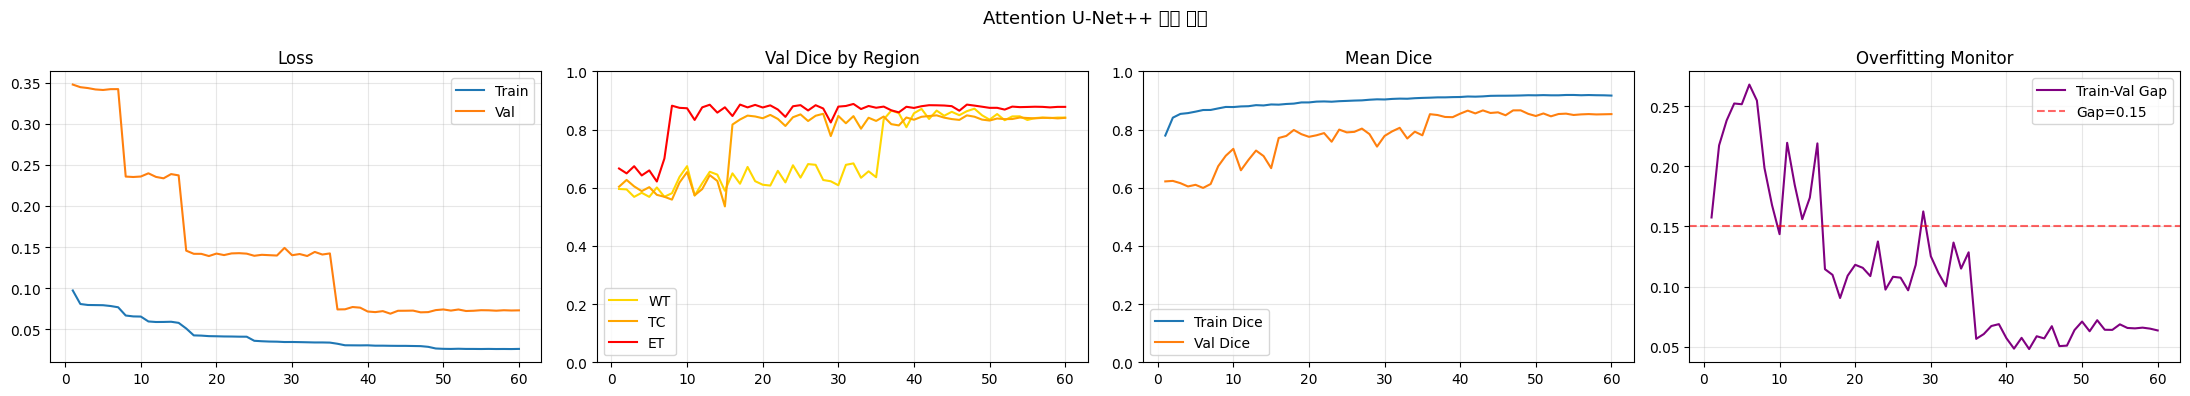

✓ 저장 완료


In [23]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(hist['epoch'], hist['train_loss'], label='Train')
axes[0].plot(hist['epoch'], hist['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist['epoch'], hist['val_WT'],   label='WT', color='gold')
axes[1].plot(hist['epoch'], hist['val_TC'],   label='TC', color='orange')
axes[1].plot(hist['epoch'], hist['val_ET'],   label='ET', color='red')
axes[1].set_title('Val Dice by Region')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hist['epoch'], hist['train_dice'], label='Train Dice')
axes[2].plot(hist['epoch'], hist['val_mean'],   label='Val Dice')
axes[2].set_title('Mean Dice')
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(hist['epoch'], hist['gap'], color='purple', label='Train-Val Gap')
axes[3].axhline(0.15, color='red', linestyle='--', alpha=0.6, label='Gap=0.15')
axes[3].set_title('Overfitting Monitor'); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle('Attention U-Net++ 학습 곡선', fontsize=13)
plt.tight_layout()
plt.savefig(WORK_DIR / 'curves_unetpp_att.png', dpi=150, bbox_inches='tight')
plt.show()

hist.to_csv(WORK_DIR / 'history_unetpp_att.csv', index=False)
print('✓ 저장 완료')

In [24]:
model.load_state_dict(torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE))
model.eval()

dice_all = []
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Test'):
        imgs  = imgs.to(DEVICE)
        logits = model(imgs)
        dice_all.append(dice_scores(logits.cpu().float(), masks.float()))

dice_res = {k: np.mean([s[k] for s in dice_all]) for k in dice_all[0]}

print('='*45)
print('  Attention U-Net++ — Test Results')
print('='*45)
for name in ['WT','TC','ET']:
    print(f'  {name:6} {dice_res[name]:8.4f}')
print('-'*45)
print(f'  Mean   {dice_res["mean"]:8.4f}')
print('='*45)

# CSV 저장
row  = {'model': 'UNetPP_Attention',
        **{f'Dice_{k}': round(dice_res[k], 4) for k in ['WT','TC','ET','mean']}}
path = WORK_DIR / 'metrics_all_models.csv'
df   = pd.read_csv(path) if path.exists() else pd.DataFrame()
pd.concat([df, pd.DataFrame([row])], ignore_index=True).to_csv(path, index=False)
print(f'✓ {path} 저장 완료')

Test: 100%|██████████| 1137/1137 [03:26<00:00,  5.51it/s]


  Attention U-Net++ — Test Results
  WT       0.8545
  TC       0.8540
  ET       0.8688
---------------------------------------------
  Mean     0.8591
✓ /Users/baiohelseu/brats_work/metrics_all_models.csv 저장 완료


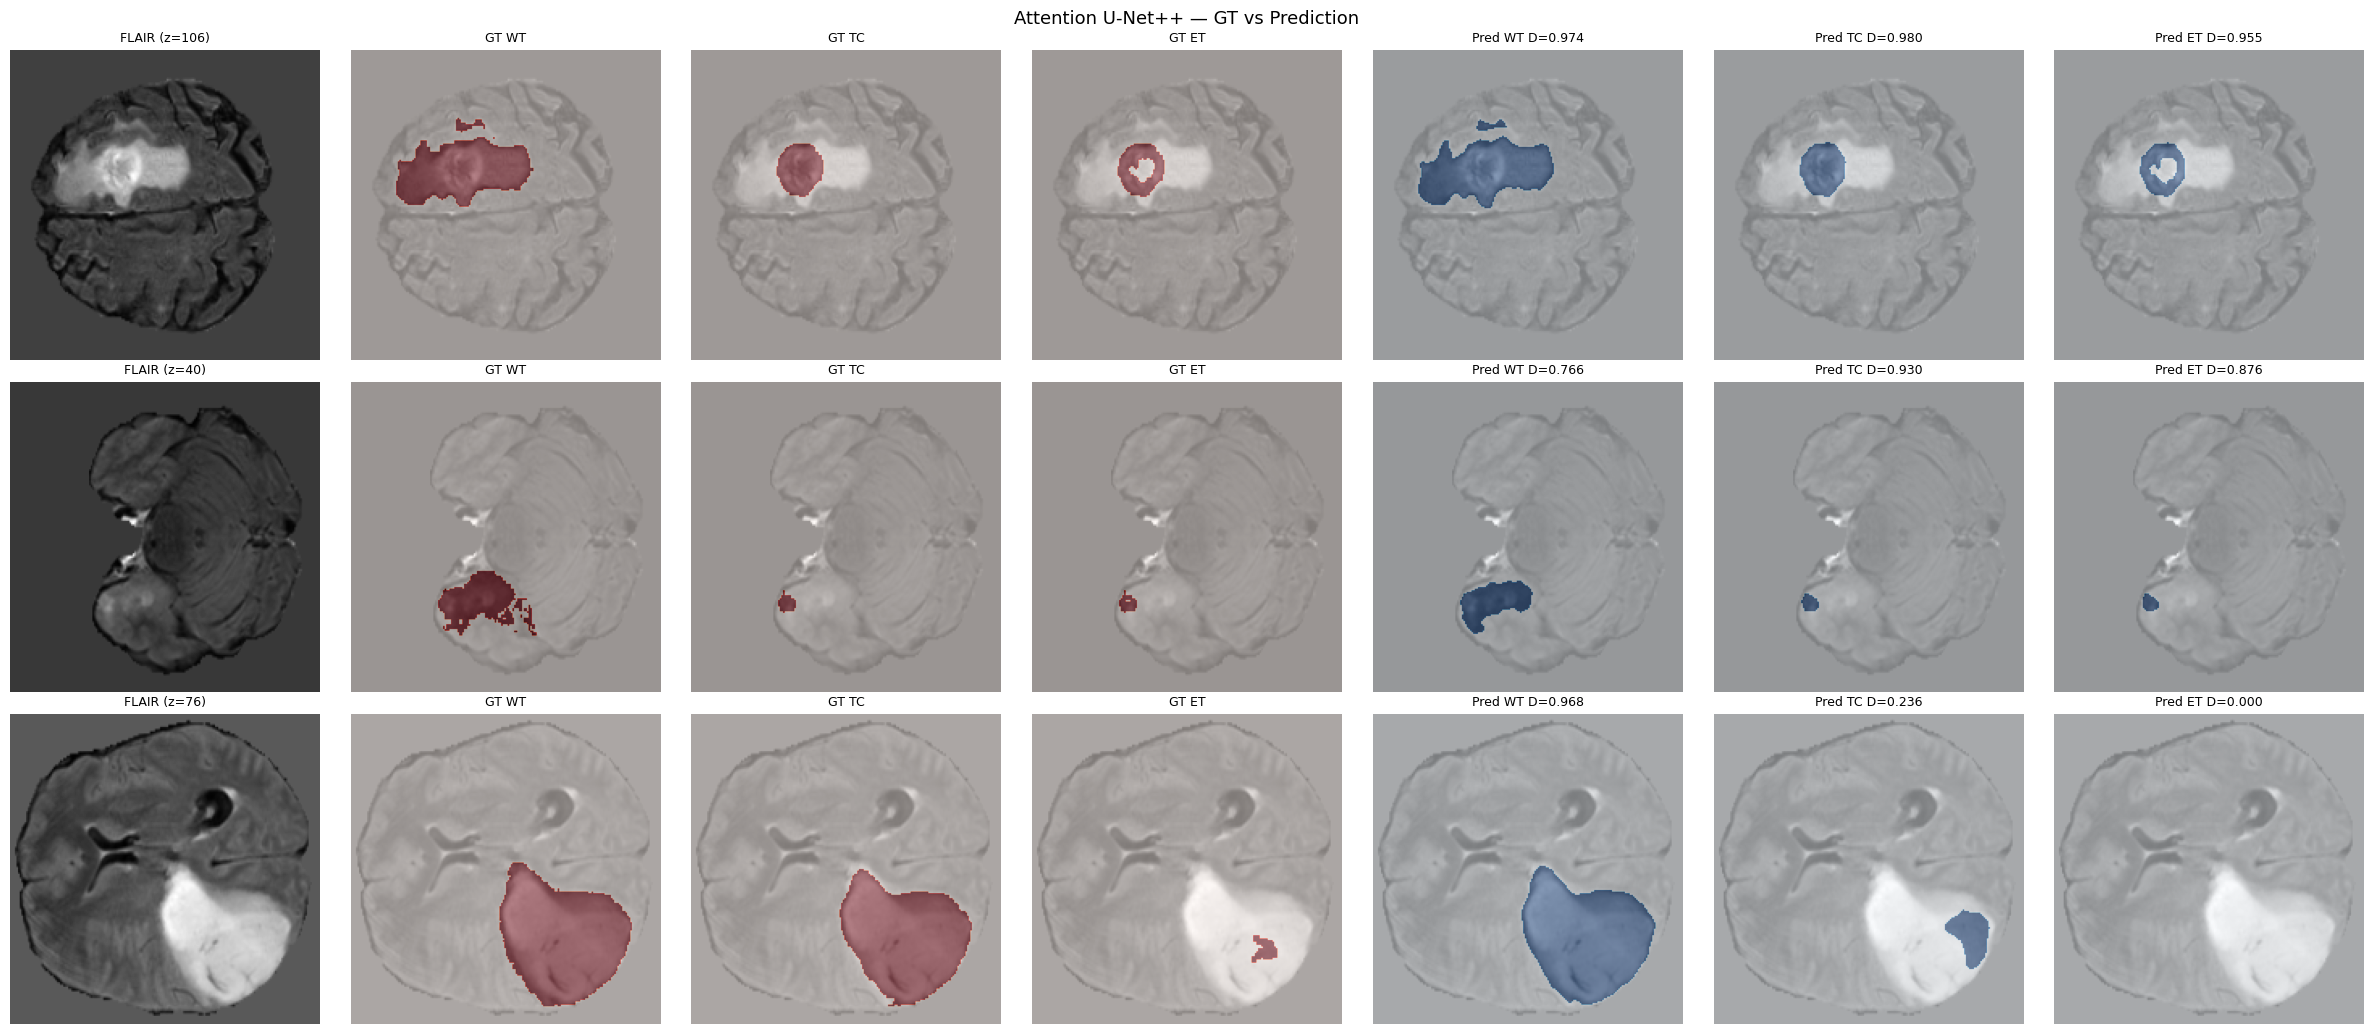

In [25]:
def visualize_predictions(model, dataset, device, n=3, thr=0.5):
    model.eval()
    indices = random.sample(range(len(dataset.all_samples)), n)
    fig, axes = plt.subplots(n, 7, figsize=(24, 3.5 * n))
    if n == 1: axes = axes[np.newaxis, :]

    with torch.no_grad():
        for row_i, sample_i in enumerate(indices):
            pid, z = dataset.all_samples[sample_i]
            img_t, mask_t = dataset[sample_i]
            logit = model(img_t.unsqueeze(0).to(device))
            pred  = (torch.sigmoid(logit.cpu().float()) > thr).squeeze(0)

            # FLAIR channel (index 8 = 중앙 slice의 첫번째 modality)
            flair = img_t[2*N_MODALITY].numpy()  # 중앙 slice, flair channel (index 0 of center)

            axes[row_i, 0].imshow(flair, cmap='gray')
            axes[row_i, 0].set_title(f'FLAIR (z={z})', fontsize=9)
            axes[row_i, 0].axis('off')

            for c, name in enumerate(['WT','TC','ET']):
                d = dice_scores(logit.cpu().float(), mask_t.unsqueeze(0))[name]
                axes[row_i, 1+c].imshow(flair, cmap='gray')
                axes[row_i, 1+c].imshow(mask_t[c].numpy(), alpha=0.5, cmap='Reds', vmin=0, vmax=1)
                axes[row_i, 1+c].set_title(f'GT {name}', fontsize=9); axes[row_i, 1+c].axis('off')

                axes[row_i, 4+c].imshow(flair, cmap='gray')
                axes[row_i, 4+c].imshow(pred[c].numpy(), alpha=0.5, cmap='Blues', vmin=0, vmax=1)
                axes[row_i, 4+c].set_title(f'Pred {name} D={d:.3f}', fontsize=9)
                axes[row_i, 4+c].axis('off')

    plt.suptitle('Attention U-Net++ — GT vs Prediction', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'viz_unetpp_att.png', dpi=120, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_ds, DEVICE, n=3)